In [1]:
import numpy as np
from cellpose import plot, utils, io
import matplotlib.pyplot as plt

# Load segmentation data and image
dat = np.load('input_images/5_seg.npy', allow_pickle=True).item()
img = io.imread('input_images/5.tif')

# Create an overlay image with colored masks
mask_RGB = plot.mask_overlay(img, dat['masks'])

# Plot the image with the filled masks overlaid
plt.figure(figsize=(8, 8))
plt.imshow(mask_RGB)
plt.axis('off')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'input_images/5_seg.npy'

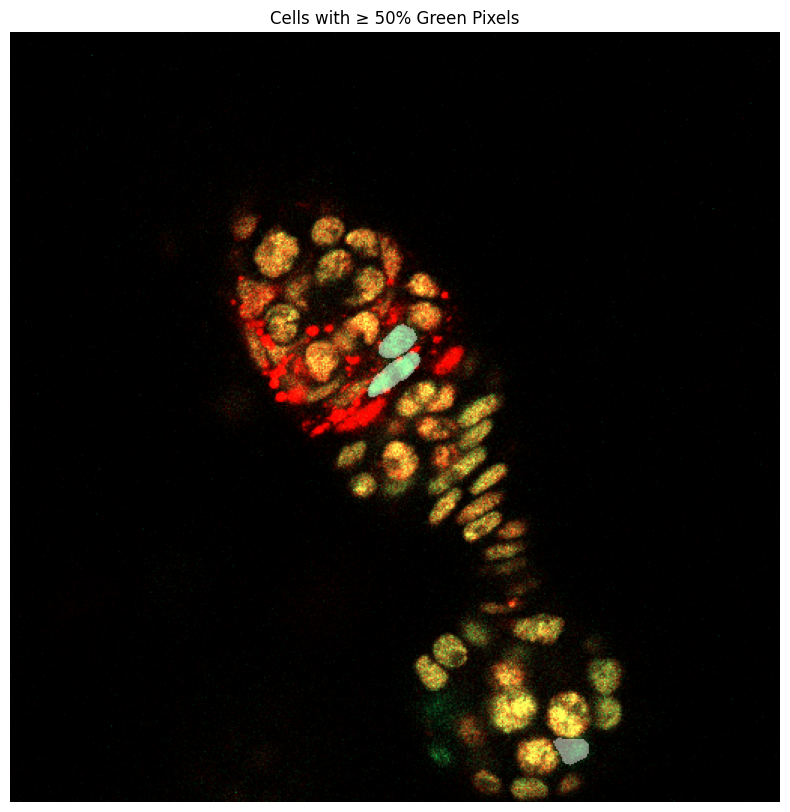

In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from cellpose import io

# -------------------------------
# Part 1: Build the dictionary
# -------------------------------

# Load segmentation data and image
dat = np.load('input_images/5_seg.npy', allow_pickle=True).item()
img = io.imread('input_images/5.tif')

# Ensure the image is in RGB (if grayscale, convert it)
if img.ndim == 2 or (img.ndim == 3 and img.shape[2] == 1):
    img = np.stack([img.squeeze()] * 3, axis=-1)

masks = dat['masks']

# Create a dictionary: key -> tuple of (y,x) coordinates for the mask pixels,
# value -> average RGB value (will be used only for visualization, if desired)
mask_dict = {}
labels = np.unique(masks)
for label in labels:
    if label == 0:  # Skip background
        continue
    cell_mask = masks == label
    coords = np.argwhere(cell_mask)
    coords_tuple = tuple(map(tuple, coords))
    avg_rgb = np.mean(img[cell_mask], axis=0)
    mask_dict[coords_tuple] = avg_rgb

# -------------------------------
# Part 2: Filter cells using HSV thresholds
# -------------------------------

# Convert the image from RGB to HSV
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

# Define HSV boundaries for green (tweak these values as needed)
lower_green = np.array([45, 50, 50])
upper_green = np.array([75, 255, 255])

# Create a binary mask for green regions using cv2.inRange
hsv_green_mask = cv2.inRange(hsv, lower_green, upper_green)
# Note: pixels within the green range will have value 255 in hsv_green_mask

# Define the minimum ratio of green pixels for a cell to be considered "green"
green_pixel_ratio_threshold = 0.5  # 50% or more pixels must be green

# Filter the dictionary based on the percentage of green pixels in each cell
filtered_dict = {}
for coords, avg_rgb in mask_dict.items():
    coords_array = np.array(coords)  # shape (N, 2)
    # Extract the green mask values for the cell's pixels
    green_vals = hsv_green_mask[coords_array[:, 0], coords_array[:, 1]]
    ratio_green = np.sum(green_vals == 255) / len(green_vals)
    if ratio_green >= green_pixel_ratio_threshold:
        filtered_dict[coords] = avg_rgb

# -------------------------------
# Part 3: Create an overlay mask and plot the filtered cells
# -------------------------------

# Create an empty boolean array to hold the overlay for filtered cells
overlay_mask = np.zeros(masks.shape, dtype=bool)
for coords in filtered_dict.keys():
    for (y, x) in coords:
        overlay_mask[y, x] = True

# Plot the original image and overlay the filtered cells in red
plt.figure(figsize=(10, 10))
plt.imshow(img)
masked_overlay = np.ma.masked_where(~overlay_mask, overlay_mask)
plt.imshow(masked_overlay, cmap='Reds', alpha=0.5)
plt.title(f'Cells with ≥ {int(green_pixel_ratio_threshold*100)}% Green Pixels')
plt.axis('off')
plt.show()

In [ ]:
import os
import glob
import numpy as np
import cv2
from cellpose import models, io

# -------------------------------
# Cellpose Segmentation Setup with Gaussian Blurring
# -------------------------------

# FOLDER TO BE SEGMENTED
base_folder = 'A1-raw-data-2'  # Folder containing subfolders (e.g., t1, t2, ... t46)
model_type = 'cyto3'          # Use 'cyto' for whole cell segmentation or 'nuclei' for nuclear segmentation
use_gpu = True               # Set to False if a GPU is not available

# Instantiate the Cellpose model
model = models.Cellpose(model_type=model_type, gpu=use_gpu)

# Get all subfolders in the base folder
subfolders = [os.path.join(base_folder, d) for d in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, d))]

# Process each subfolder
for subfolder in subfolders:
    # Get list of all TIFF images in the subfolder
    image_files = glob.glob(os.path.join(subfolder, '*.tif'))
    
    for img_file in image_files:
        # Read the image using cellpose's io.imread (supports many image formats)
        img = io.imread(img_file)
    
        # Convert grayscale images to RGB if needed
        if img.ndim == 2:
            img = np.stack([img] * 3, axis=-1)
        elif img.ndim == 3 and img.shape[2] == 1:
            img = np.concatenate([img] * 3, axis=2)
    
        # Apply Gaussian blurring to the image before segmentation
        # Adjust the kernel size (5,5) and sigma value (0) as needed
        img_blurred = cv2.GaussianBlur(img, (5, 5), 0)
    
        # For RGB images, using channels=[0,0] tells Cellpose to use the entire image
        channels = [0, 0]
    
        # Run the segmentation using Cellpose on the blurred image
        masks, flows, styles, diams = model.eval(img_blurred, channels=channels)
    
        # Save the segmentation results in a dictionary (the 'masks' key is used by the filtering cell)
        seg_data = {'masks': masks, 'flows': flows, 'styles': styles, 'diams': diams}
    
        # Construct the segmentation file name (e.g., 'image_seg.npy')
        base_name = os.path.splitext(os.path.basename(img_file))[0]
        seg_file = os.path.join(subfolder, base_name + '_seg.npy')
    
        np.save(seg_file, seg_data)
        print(f"Segmented {base_name} in folder {os.path.basename(subfolder)} and saved to {seg_file}.")


Segmented 15 in folder t16 and saved to A1-raw-data-2/t16/15_seg.npy.
Segmented 1 in folder t16 and saved to A1-raw-data-2/t16/1_seg.npy.
Segmented 5 in folder t16 and saved to A1-raw-data-2/t16/5_seg.npy.
Segmented 6 in folder t16 and saved to A1-raw-data-2/t16/6_seg.npy.
Segmented 4 in folder t16 and saved to A1-raw-data-2/t16/4_seg.npy.
Segmented 9 in folder t16 and saved to A1-raw-data-2/t16/9_seg.npy.
Segmented 10 in folder t16 and saved to A1-raw-data-2/t16/10_seg.npy.
Segmented 8 in folder t16 and saved to A1-raw-data-2/t16/8_seg.npy.
Segmented 14 in folder t16 and saved to A1-raw-data-2/t16/14_seg.npy.
Segmented 3 in folder t16 and saved to A1-raw-data-2/t16/3_seg.npy.
Segmented 12 in folder t16 and saved to A1-raw-data-2/t16/12_seg.npy.
Segmented 11 in folder t16 and saved to A1-raw-data-2/t16/11_seg.npy.
Segmented 13 in folder t16 and saved to A1-raw-data-2/t16/13_seg.npy.
Segmented 7 in folder t16 and saved to A1-raw-data-2/t16/7_seg.npy.
Segmented 2 in folder t16 and saved 

Segmented 5 in folder t13 and saved to A1-raw-data-2/t13/5_seg.npy.
Segmented 6 in folder t13 and saved to A1-raw-data-2/t13/6_seg.npy.
Segmented 4 in folder t13 and saved to A1-raw-data-2/t13/4_seg.npy.
Segmented 9 in folder t13 and saved to A1-raw-data-2/t13/9_seg.npy.
Segmented 10 in folder t13 and saved to A1-raw-data-2/t13/10_seg.npy.
Segmented 8 in folder t13 and saved to A1-raw-data-2/t13/8_seg.npy.
Segmented 14 in folder t13 and saved to A1-raw-data-2/t13/14_seg.npy.
Segmented 3 in folder t13 and saved to A1-raw-data-2/t13/3_seg.npy.
Segmented 12 in folder t13 and saved to A1-raw-data-2/t13/12_seg.npy.
Segmented 11 in folder t13 and saved to A1-raw-data-2/t13/11_seg.npy.
Segmented 13 in folder t13 and saved to A1-raw-data-2/t13/13_seg.npy.
Segmented 7 in folder t13 and saved to A1-raw-data-2/t13/7_seg.npy.
Segmented 2 in folder t13 and saved to A1-raw-data-2/t13/2_seg.npy.
Segmented 15 in folder t25 and saved to A1-raw-data-2/t25/15_seg.npy.
Segmented 1 in folder t25 and saved 

Segmented 9 in folder t46 and saved to A1-raw-data-2/t46/9_seg.npy.
Segmented 10 in folder t46 and saved to A1-raw-data-2/t46/10_seg.npy.
Segmented 8 in folder t46 and saved to A1-raw-data-2/t46/8_seg.npy.
Segmented 14 in folder t46 and saved to A1-raw-data-2/t46/14_seg.npy.
Segmented 3 in folder t46 and saved to A1-raw-data-2/t46/3_seg.npy.
Segmented 12 in folder t46 and saved to A1-raw-data-2/t46/12_seg.npy.
Segmented 11 in folder t46 and saved to A1-raw-data-2/t46/11_seg.npy.
Segmented 13 in folder t46 and saved to A1-raw-data-2/t46/13_seg.npy.
Segmented 7 in folder t46 and saved to A1-raw-data-2/t46/7_seg.npy.
Segmented 2 in folder t46 and saved to A1-raw-data-2/t46/2_seg.npy.
Segmented 15 in folder t18 and saved to A1-raw-data-2/t18/15_seg.npy.
Segmented 1 in folder t18 and saved to A1-raw-data-2/t18/1_seg.npy.
Segmented 5 in folder t18 and saved to A1-raw-data-2/t18/5_seg.npy.
Segmented 6 in folder t18 and saved to A1-raw-data-2/t18/6_seg.npy.
Segmented 4 in folder t18 and saved 

Segmented 8 in folder t38 and saved to A1-raw-data-2/t38/8_seg.npy.
Segmented 14 in folder t38 and saved to A1-raw-data-2/t38/14_seg.npy.
Segmented 3 in folder t38 and saved to A1-raw-data-2/t38/3_seg.npy.
Segmented 12 in folder t38 and saved to A1-raw-data-2/t38/12_seg.npy.
Segmented 11 in folder t38 and saved to A1-raw-data-2/t38/11_seg.npy.
Segmented 13 in folder t38 and saved to A1-raw-data-2/t38/13_seg.npy.
Segmented 7 in folder t38 and saved to A1-raw-data-2/t38/7_seg.npy.
Segmented 2 in folder t38 and saved to A1-raw-data-2/t38/2_seg.npy.
Segmented 15 in folder t15 and saved to A1-raw-data-2/t15/15_seg.npy.
Segmented 1 in folder t15 and saved to A1-raw-data-2/t15/1_seg.npy.
Segmented 5 in folder t15 and saved to A1-raw-data-2/t15/5_seg.npy.
Segmented 6 in folder t15 and saved to A1-raw-data-2/t15/6_seg.npy.
Segmented 4 in folder t15 and saved to A1-raw-data-2/t15/4_seg.npy.
Segmented 9 in folder t15 and saved to A1-raw-data-2/t15/9_seg.npy.
Segmented 10 in folder t15 and saved t

Segmented 14 in folder t45 and saved to A1-raw-data-2/t45/14_seg.npy.
Segmented 3 in folder t45 and saved to A1-raw-data-2/t45/3_seg.npy.
Segmented 12 in folder t45 and saved to A1-raw-data-2/t45/12_seg.npy.
Segmented 11 in folder t45 and saved to A1-raw-data-2/t45/11_seg.npy.
Segmented 13 in folder t45 and saved to A1-raw-data-2/t45/13_seg.npy.
Segmented 7 in folder t45 and saved to A1-raw-data-2/t45/7_seg.npy.
Segmented 2 in folder t45 and saved to A1-raw-data-2/t45/2_seg.npy.
Segmented 15 in folder t11 and saved to A1-raw-data-2/t11/15_seg.npy.
Segmented 1 in folder t11 and saved to A1-raw-data-2/t11/1_seg.npy.
Segmented 5 in folder t11 and saved to A1-raw-data-2/t11/5_seg.npy.
Segmented 6 in folder t11 and saved to A1-raw-data-2/t11/6_seg.npy.
Segmented 4 in folder t11 and saved to A1-raw-data-2/t11/4_seg.npy.
Segmented 9 in folder t11 and saved to A1-raw-data-2/t11/9_seg.npy.
Segmented 10 in folder t11 and saved to A1-raw-data-2/t11/10_seg.npy.
Segmented 8 in folder t11 and saved 

no seeds found in get_masks_torch - no masks found.


Segmented 2 in folder t11 and saved to A1-raw-data-2/t11/2_seg.npy.
Segmented 15 in folder t4 and saved to A1-raw-data-2/t4/15_seg.npy.
Segmented 1 in folder t4 and saved to A1-raw-data-2/t4/1_seg.npy.
Segmented 5 in folder t4 and saved to A1-raw-data-2/t4/5_seg.npy.
Segmented 6 in folder t4 and saved to A1-raw-data-2/t4/6_seg.npy.
Segmented 4 in folder t4 and saved to A1-raw-data-2/t4/4_seg.npy.
Segmented 9 in folder t4 and saved to A1-raw-data-2/t4/9_seg.npy.
Segmented 10 in folder t4 and saved to A1-raw-data-2/t4/10_seg.npy.
Segmented 8 in folder t4 and saved to A1-raw-data-2/t4/8_seg.npy.
Segmented 14 in folder t4 and saved to A1-raw-data-2/t4/14_seg.npy.
Segmented 3 in folder t4 and saved to A1-raw-data-2/t4/3_seg.npy.
Segmented 12 in folder t4 and saved to A1-raw-data-2/t4/12_seg.npy.
Segmented 11 in folder t4 and saved to A1-raw-data-2/t4/11_seg.npy.
Segmented 13 in folder t4 and saved to A1-raw-data-2/t4/13_seg.npy.
Segmented 7 in folder t4 and saved to A1-raw-data-2/t4/7_seg.n

Segmented 15 in folder t40 and saved to A1-raw-data-2/t40/15_seg.npy.
Segmented 1 in folder t40 and saved to A1-raw-data-2/t40/1_seg.npy.
Segmented 5 in folder t40 and saved to A1-raw-data-2/t40/5_seg.npy.
Segmented 6 in folder t40 and saved to A1-raw-data-2/t40/6_seg.npy.
Segmented 4 in folder t40 and saved to A1-raw-data-2/t40/4_seg.npy.
Segmented 9 in folder t40 and saved to A1-raw-data-2/t40/9_seg.npy.
Segmented 10 in folder t40 and saved to A1-raw-data-2/t40/10_seg.npy.
Segmented 8 in folder t40 and saved to A1-raw-data-2/t40/8_seg.npy.
Segmented 14 in folder t40 and saved to A1-raw-data-2/t40/14_seg.npy.
Segmented 3 in folder t40 and saved to A1-raw-data-2/t40/3_seg.npy.
Segmented 12 in folder t40 and saved to A1-raw-data-2/t40/12_seg.npy.
Segmented 11 in folder t40 and saved to A1-raw-data-2/t40/11_seg.npy.
Segmented 13 in folder t40 and saved to A1-raw-data-2/t40/13_seg.npy.
Segmented 7 in folder t40 and saved to A1-raw-data-2/t40/7_seg.npy.
Segmented 2 in folder t40 and saved 

# Cell Isolation

In [ ]:
import os
import glob
import numpy as np
import cv2
import matplotlib.pyplot as plt
from cellpose import io

# -------------------------------
# Configuration and Setup
# -------------------------------
base_input_folder = 'jeeshtest'  # Base folder containing subfolders with images and segmentation files
output_folder_images = 'output-images-5'       # For saving overlay images
output_folder_outlines = 'output-outlines-5'    # For saving cell outlines

# Create output directories if they don't exist
os.makedirs(output_folder_images, exist_ok=True)
os.makedirs(output_folder_outlines, exist_ok=True)

# Recursively find all segmentation files (assumed to end with '_seg.npy')
segmentation_files = glob.glob(os.path.join(base_input_folder, '**', '*_seg.npy'), recursive=True)

# Define HSV thresholds and green pixel ratio threshold
lower_green = np.array([40, 45, 45])
upper_green = np.array([80, 255, 255])
green_pixel_ratio_threshold = 0.50  # 50% or more pixels must be green

# -------------------------------
# Process each file pair in the folder tree
# -------------------------------
for seg_file in segmentation_files:
    # Determine the base name (e.g., "image_seg.npy" -> "image")
    base_name = os.path.basename(seg_file).replace('_seg.npy', '')
    
    # The corresponding image is assumed to be in the same folder with a .tif extension
    img_file = os.path.join(os.path.dirname(seg_file), base_name + '.tif')
    
    # Check if the corresponding image file exists
    if not os.path.exists(img_file):
        print(f"Image file {img_file} not found for segmentation file {seg_file}. Skipping.")
        continue

    # Determine subfolder relative to the base_input_folder for output organization
    subfolder = os.path.relpath(os.path.dirname(seg_file), base_input_folder)
    out_img_folder = os.path.join(output_folder_images, subfolder)
    out_outline_folder = os.path.join(output_folder_outlines, subfolder)
    os.makedirs(out_img_folder, exist_ok=True)
    os.makedirs(out_outline_folder, exist_ok=True)
    
    print(f"Processing {base_name} in folder {subfolder}...")

    # -------------------------------
    # Part 1: Load data and build the mask dictionary
    # -------------------------------
    dat = np.load(seg_file, allow_pickle=True).item()
    img = io.imread(img_file)

    # Ensure the image is in RGB (if grayscale, convert it)
    if img.ndim == 2 or (img.ndim == 3 and img.shape[2] == 1):
        img = np.stack([img.squeeze()] * 3, axis=-1)

    masks = dat['masks']

    # Create a dictionary: key -> tuple of (y,x) coordinates for the mask pixels,
    # value -> average RGB value (for visualization if desired)
    mask_dict = {}
    labels = np.unique(masks)
    for label in labels:
        if label == 0:  # Skip background
            continue
        cell_mask = masks == label
        coords = np.argwhere(cell_mask)
        coords_tuple = tuple(map(tuple, coords))
        avg_rgb = np.mean(img[cell_mask], axis=0)
        mask_dict[coords_tuple] = avg_rgb

    # -------------------------------
    # Part 2: Filter cells using HSV thresholds
    # -------------------------------
    # Convert the image from RGB to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    # Create a binary mask for green regions
    hsv_green_mask = cv2.inRange(hsv, lower_green, upper_green)

    filtered_dict = {}
    for coords, avg_rgb in mask_dict.items():
        coords_array = np.array(coords)  # shape (N, 2)
        # Extract the green mask values for the cell's pixels
        green_vals = hsv_green_mask[coords_array[:, 0], coords_array[:, 1]]
        ratio_green = np.sum(green_vals == 255) / len(green_vals)
        if ratio_green >= green_pixel_ratio_threshold:
            filtered_dict[coords] = avg_rgb

    # -------------------------------
    # Part 3: Create a black background with just the green cells and save the image
    # -------------------------------
    # Create a black background image (all zeros)
    green_cells_image = np.zeros(img.shape, dtype=np.uint8)
    
    # Set the green cells to green color (0, 255, 0) on the black background
    for coords in filtered_dict.keys():
        coords_array = np.array(coords)
        # Use a pure green color for all cells
        green_cells_image[coords_array[:, 0], coords_array[:, 1]] = [0, 255, 0]  # RGB for green

    # Save the green cells image to the output folder (preserving subfolder structure)
    output_green_cells_file = os.path.join(out_img_folder, base_name + '_green_cells.png')
    
    # Setup the figure with tight layout and no edge padding
    plt.figure(figsize=(10, 10))
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)  # Remove internal padding
    plt.imshow(green_cells_image)
    plt.axis('off')  # Turn off axis
    
    # Save with tight bounding box, no padding, and black background
    plt.savefig(output_green_cells_file, 
                bbox_inches='tight',  # Remove any extra whitespace
                pad_inches=0,         # Remove all padding
                facecolor='black',    # Make figure background black
                dpi=300)              # Higher DPI for better quality
    plt.close()

    # -------------------------------
    # Part 4: Extract cell outlines and write to file
    # -------------------------------
    outline_file = os.path.join(out_outline_folder, base_name + '_outlines.txt')
    with open(outline_file, "w") as f:
        for coords in filtered_dict.keys():
            # Create a binary image for this cell mask
            cell_mask_img = np.zeros(masks.shape, dtype=np.uint8)
            coords_np = np.array(coords)
            cell_mask_img[coords_np[:, 0], coords_np[:, 1]] = 255

            # Find contours; using RETR_EXTERNAL to get only the outer boundary
            contours, _ = cv2.findContours(cell_mask_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if len(contours) == 0:
                continue

            # Choose the largest contour (in case there are multiple)
            largest_contour = max(contours, key=cv2.contourArea)
            largest_contour = largest_contour.squeeze()
            # Ensure the contour is 2D (in case it's only a single point)
            if largest_contour.ndim == 1:
                largest_contour = np.expand_dims(largest_contour, axis=0)

            # Format the contour as "x,y,x,y,..." (note: OpenCV contours are in (x,y) order)
            coord_pairs = [f"{pt[0]},{pt[1]}" for pt in largest_contour]
            outline_str = ",".join(coord_pairs)
            f.write(outline_str + "\n")

    print(f"Finished processing {base_name} in folder {subfolder}.")
    print(f" - Green cells image saved to: {output_green_cells_file}")
    print(f" - Outlines saved to: {outline_file}")

Processing 13 in folder t1...
Finished processing 13 in folder t1.
 - Green cells image saved to: output-images-5/t1/13_green_cells.png
 - Outlines saved to: output-outlines-5/t1/13_outlines.txt
Processing 9 in folder t1...
Finished processing 9 in folder t1.
 - Green cells image saved to: output-images-5/t1/9_green_cells.png
 - Outlines saved to: output-outlines-5/t1/9_outlines.txt
Processing 1 in folder t1...
Finished processing 1 in folder t1.
 - Green cells image saved to: output-images-5/t1/1_green_cells.png
 - Outlines saved to: output-outlines-5/t1/1_outlines.txt
Processing 12 in folder t1...
Finished processing 12 in folder t1.
 - Green cells image saved to: output-images-5/t1/12_green_cells.png
 - Outlines saved to: output-outlines-5/t1/12_outlines.txt
Processing 15 in folder t1...
Finished processing 15 in folder t1.
 - Green cells image saved to: output-images-5/t1/15_green_cells.png
 - Outlines saved to: output-outlines-5/t1/15_outlines.txt
Processing 5 in folder t1...
Fini